In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration pour les visualisations
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Chemins des données
data_path = Path('/Users/martinvalentine/Downloads/liar_dataset-master')

# Vérifier les fichiers disponibles
print("Fichiers disponibles dans le dataset LIAR:")
for file in sorted(data_path.glob('*')):
    if file.is_file():
        size = file.stat().st_size / (1024*1024)  # En MB
        print(f"  - {file.name}: {size:.2f} MB")

Fichiers disponibles dans le dataset LIAR:
  - README: 0.00 MB
  - analise_sentimento_ok.ipynb: 0.02 MB
  - test.tsv: 0.29 MB
  - test_pos.csv: 0.12 MB
  - train.tsv: 2.30 MB
  - train_pos.csv: 0.99 MB
  - valid.tsv: 0.29 MB
  - valid_pos.csv: 0.11 MB


## 1. Chargement des Données TSV (Train, Test, Valid)

In [2]:
# Configuration des colonnes TSV selon la documentation
columns_tsv = [
    'id', 'label', 'statement', 'subject', 'speaker', 'job_title', 
    'state', 'party', 'barely_true', 'false', 'half_true', 'mostly_true', 
    'pants_on_fire', 'context'
]

# Charger les données
train_data = pd.read_csv(data_path / 'train.tsv', sep='\t', header=None, names=columns_tsv)
test_data = pd.read_csv(data_path / 'test.tsv', sep='\t', header=None, names=columns_tsv)
valid_data = pd.read_csv(data_path / 'valid.tsv', sep='\t', header=None, names=columns_tsv)

print("=" * 80)
print("RÉSUMÉ DES DONNÉES TSV")
print("=" * 80)
print(f"\n📊 TRAIN SET: {train_data.shape[0]:,} déclarations × {train_data.shape[1]} colonnes")
print(f"TEST SET:  {test_data.shape[0]:,} déclarations × {test_data.shape[1]} colonnes")
print(f"VALID SET: {valid_data.shape[0]:,} déclarations × {valid_data.shape[1]} colonnes")
print(f"\nTotal: {train_data.shape[0] + test_data.shape[0] + valid_data.shape[0]:,} déclarations")

print("\n" + "=" * 80)
print("COLONNES DU DATASET:")
print("=" * 80)
for i, col in enumerate(columns_tsv, 1):
    print(f"{i:2d}. {col}")

print("\n" + "=" * 80)
print("APERÇU DES PREMIÈRES LIGNES (Train)")
print("=" * 80)
print(train_data.head(2))

RÉSUMÉ DES DONNÉES TSV

📊 TRAIN SET: 10,240 déclarations × 14 colonnes
TEST SET:  1,267 déclarations × 14 colonnes
VALID SET: 1,284 déclarations × 14 colonnes

Total: 12,791 déclarations

COLONNES DU DATASET:
 1. id
 2. label
 3. statement
 4. subject
 5. speaker
 6. job_title
 7. state
 8. party
 9. barely_true
10. false
11. half_true
12. mostly_true
13. pants_on_fire
14. context

APERÇU DES PREMIÈRES LIGNES (Train)
           id      label                                          statement  \
0   2635.json      false  Says the Annies List political group supports ...   
1  10540.json  half-true  When did the decline of coal start? It started...   

                              subject         speaker             job_title  \
0                            abortion    dwayne-bohac  State representative   
1  energy,history,job-accomplishments  scott-surovell        State delegate   

      state       party  barely_true  false  half_true  mostly_true  \
0     Texas  republican         

## 2. Distribution des Labels (Vérité des Déclarations)


DISTRIBUTION DES LABELS


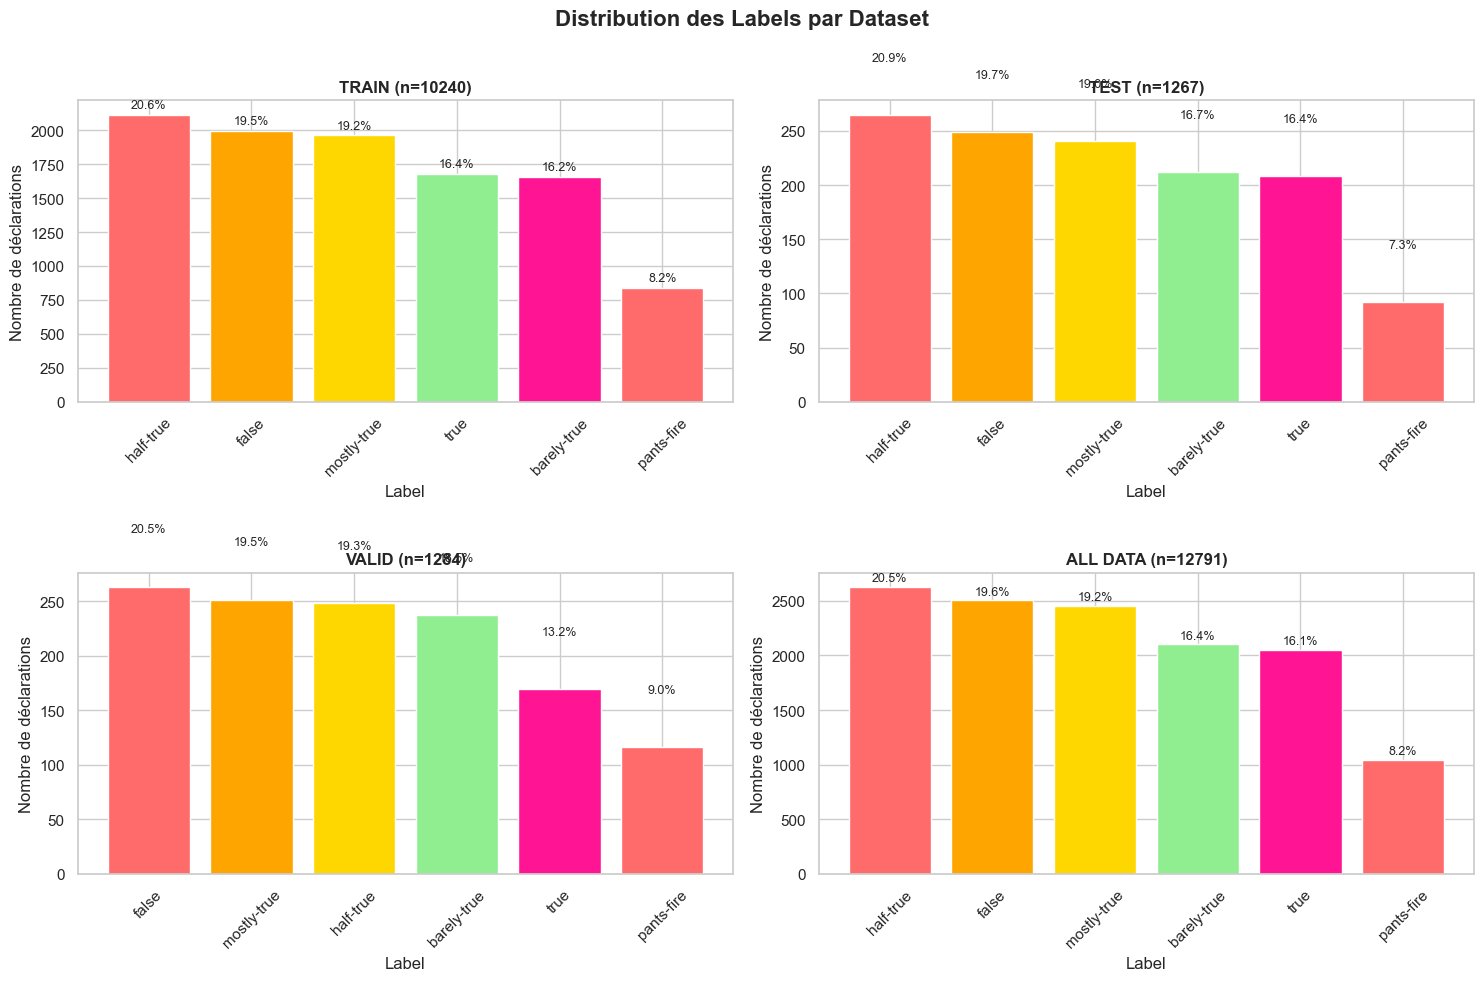


DISTRIBUTION DÉTAILLÉE PAR DATASET:
--------------------------------------------------------------------------------

TRAIN:
  half-true           :   2114 (20.64%)
  false               :   1995 (19.48%)
  mostly-true         :   1962 (19.16%)
  true                :   1676 (16.37%)
  barely-true         :   1654 (16.15%)
  pants-fire          :    839 ( 8.19%)
  TOTAL               :  10240

TEST:
  half-true           :    265 (20.92%)
  false               :    249 (19.65%)
  mostly-true         :    241 (19.02%)
  barely-true         :    212 (16.73%)
  true                :    208 (16.42%)
  pants-fire          :     92 ( 7.26%)
  TOTAL               :   1267

VALID:
  false               :    263 (20.48%)
  mostly-true         :    251 (19.55%)
  half-true           :    248 (19.31%)
  barely-true         :    237 (18.46%)
  true                :    169 (13.16%)
  pants-fire          :    116 ( 9.03%)
  TOTAL               :   1284

ALL:
  half-true           :   2627 (20.54%)


In [3]:
# Distribution des labels
print("\n" + "=" * 80)
print("DISTRIBUTION DES LABELS")
print("=" * 80)

labels_all_data = pd.concat([train_data, test_data, valid_data], ignore_index=True)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution des Labels par Dataset', fontsize=16, fontweight='bold')

datasets = [
    ('TRAIN', train_data, axes[0, 0]),
    ('TEST', test_data, axes[0, 1]),
    ('VALID', valid_data, axes[1, 0]),
    ('ALL DATA', labels_all_data, axes[1, 1])
]

for name, data, ax in datasets:
    label_counts = data['label'].value_counts()
    colors = ['#FF6B6B', '#FFA500', '#FFD700', '#90EE90', '#FF1493']
    ax.bar(label_counts.index, label_counts.values, color=colors[:len(label_counts)])
    ax.set_title(f'{name} (n={len(data)})', fontweight='bold')
    ax.set_ylabel('Nombre de déclarations')
    ax.set_xlabel('Label')
    
    # Ajouter les pourcentages
    for i, (label, count) in enumerate(label_counts.items()):
        pct = 100 * count / len(data)
        ax.text(i, count + 50, f'{pct:.1f}%', ha='center', fontsize=9)
    
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statistiques détaillées
print("\nDISTRIBUTION DÉTAILLÉE PAR DATASET:")
print("-" * 80)

for name, data in [('TRAIN', train_data), ('TEST', test_data), ('VALID', valid_data), ('ALL', labels_all_data)]:
    print(f"\n{name}:")
    label_dist = data['label'].value_counts()
    for label, count in label_dist.items():
        pct = 100 * count / len(data)
        print(f"  {label:20s}: {count:6d} ({pct:5.2f}%)")
    print(f"  {'TOTAL':20s}: {len(data):6d}")

# Vérifier l'équilibre des classes
print("\n" + "=" * 80)
print("ANALYSE D'ÉQUILIBRE DES CLASSES")
print("=" * 80)
print("\nRapport entre classe minoritaire et majoritaire (idealement proche de 1):")
for name, data in [('TRAIN', train_data), ('TEST', test_data), ('VALID', valid_data)]:
    label_counts = data['label'].value_counts()
    ratio = label_counts.min() / label_counts.max()
    print(f"{name:10s}: {ratio:.3f}")
    if ratio < 0.5:
        print(f"           ⚠️  DÉSÉQUILIBRÉ (ratio < 0.5)")
    else:
        print(f"           ✓ Équilibré")

## 3. Analyse des Caractéristiques Textuelles


ANALYSE DES CARACTÉRISTIQUES TEXTUELLES

STATISTIQUES SUR LA LONGUEUR DES DÉCLARATIONS (nombre de mots):
--------------------------------------------------------------------------------

TRAIN:
  Moyenne: 18.0 mots
  Médiane: 17.0 mots
  Min: 2 mots
  Max: 467 mots
  Std: 9.7 mots

TEST:
  Moyenne: 18.4 mots
  Médiane: 16.0 mots
  Min: 2 mots
  Max: 431 mots
  Std: 14.9 mots

VALID:
  Moyenne: 17.9 mots
  Médiane: 17.0 mots
  Min: 3 mots
  Max: 57 mots
  Std: 7.7 mots


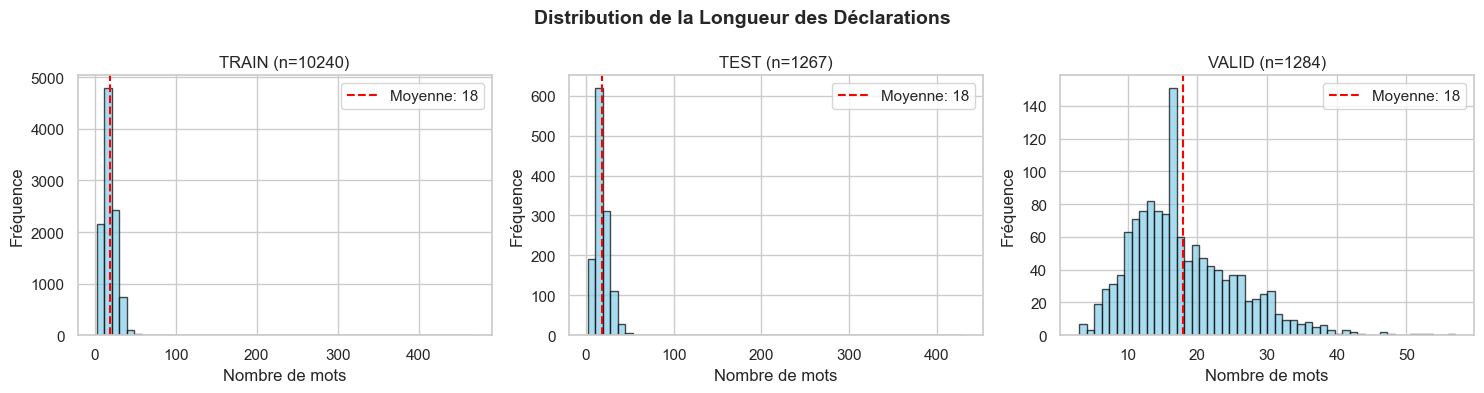


--------------------------------------------------------------------------------
LONGUEUR MOYENNE PAR LABEL (ALL DATA):
--------------------------------------------------------------------------------
              mean  median    std  count
label                                   
barely-true  18.15    17.0   7.79   2103
false        16.87    15.0   9.60   2507
half-true    18.96    18.0  11.42   2627
mostly-true  18.50    17.0  11.90   2454
pants-fire   17.24    16.0   7.48   1047
true         18.03    16.0   9.83   2053


In [4]:
# Analyse textuelle
print("\n" + "=" * 80)
print("ANALYSE DES CARACTÉRISTIQUES TEXTUELLES")
print("=" * 80)

# Ajouter les longueurs des textes
for data in [train_data, test_data, valid_data]:
    data['statement_length'] = data['statement'].apply(lambda x: len(str(x).split()) if pd.notna(x) else 0)

print("\nSTATISTIQUES SUR LA LONGUEUR DES DÉCLARATIONS (nombre de mots):")
print("-" * 80)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Distribution de la Longueur des Déclarations', fontsize=14, fontweight='bold')

for data_name, data, ax in [('TRAIN', train_data, axes[0]), ('TEST', test_data, axes[1]), ('VALID', valid_data, axes[2])]:
    print(f"\n{data_name}:")
    print(f"  Moyenne: {data['statement_length'].mean():.1f} mots")
    print(f"  Médiane: {data['statement_length'].median():.1f} mots")
    print(f"  Min: {data['statement_length'].min()} mots")
    print(f"  Max: {data['statement_length'].max()} mots")
    print(f"  Std: {data['statement_length'].std():.1f} mots")
    
    ax.hist(data['statement_length'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'{data_name} (n={len(data)})')
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Fréquence')
    ax.axvline(data['statement_length'].mean(), color='red', linestyle='--', label=f'Moyenne: {data["statement_length"].mean():.0f}')
    ax.legend()

plt.tight_layout()
plt.show()

# Longueur par label
print("\n" + "-" * 80)
print("LONGUEUR MOYENNE PAR LABEL (ALL DATA):")
print("-" * 80)

all_data_combined = pd.concat([train_data, test_data, valid_data], ignore_index=True)
length_by_label = all_data_combined.groupby('label')['statement_length'].agg(['mean', 'median', 'std', 'count'])
print(length_by_label.round(2))

## 4. Analyse des Caractéristiques Structurelles

In [5]:
print("\n" + "=" * 80)
print("ANALYSE DES CARACTÉRISTIQUES STRUCTURELLES")
print("=" * 80)

# Orateurs top
print("\nTOP 15 ORATEURS LES PLUS ACTIFS (ALL DATA):")
print("-" * 80)
top_speakers = all_data_combined['speaker'].value_counts().head(15)
for speaker, count in top_speakers.items():
    pct = 100 * count / len(all_data_combined)
    print(f"  {speaker:40s}: {count:4d} ({pct:5.2f}%)")

# Partis politiques
print("\n\nPARTIS POLITIQUES (ALL DATA):")
print("-" * 80)
party_counts = all_data_combined['party'].value_counts()
for party, count in party_counts.items():
    if pd.notna(party):
        pct = 100 * count / len(all_data_combined)
        print(f"  {str(party):40s}: {count:4d} ({pct:5.2f}%)")

# Sujets
print("\n\nTOP 15 SUJETS LES PLUS FRÉQUENTS (ALL DATA):")
print("-" * 80)
# Les sujets sont séparés par des virgules
all_subjects = []
for subjects_str in all_data_combined['subject'].dropna():
    for subject in str(subjects_str).split(','):
        all_subjects.append(subject.strip())

subject_counts = pd.Series(all_subjects).value_counts().head(15)
for subject, count in subject_counts.items():
    pct = 100 * count / len(all_subjects)
    print(f"  {subject:40s}: {count:4d} ({pct:5.2f}%)")

# Contextes
print("\n\nCONTEXTES (LIEUX) - TOP 10 (ALL DATA):")
print("-" * 80)
context_counts = all_data_combined['context'].value_counts().head(10)
for context, count in context_counts.items():
    if pd.notna(context):
        pct = 100 * count / len(all_data_combined)
        print(f"  {str(context):40s}: {count:4d} ({pct:5.2f}%)")

# Titres de poste top
print("\n\nTOP 10 TITRES DE POSTE (ALL DATA):")
print("-" * 80)
job_counts = all_data_combined['job_title'].value_counts().head(10)
for job, count in job_counts.items():
    if pd.notna(job):
        pct = 100 * count / len(all_data_combined)
        print(f"  {str(job):40s}: {count:4d} ({pct:5.2f}%)")


ANALYSE DES CARACTÉRISTIQUES STRUCTURELLES

TOP 15 ORATEURS LES PLUS ACTIFS (ALL DATA):
--------------------------------------------------------------------------------
  barack-obama                            :  611 ( 4.78%)
  donald-trump                            :  343 ( 2.68%)
  hillary-clinton                         :  297 ( 2.32%)
  mitt-romney                             :  212 ( 1.66%)
  john-mccain                             :  189 ( 1.48%)
  scott-walker                            :  183 ( 1.43%)
  chain-email                             :  178 ( 1.39%)
  rick-perry                              :  173 ( 1.35%)
  marco-rubio                             :  153 ( 1.20%)
  rick-scott                              :  150 ( 1.17%)
  ted-cruz                                :  118 ( 0.92%)
  bernie-s                                :  106 ( 0.83%)
  chris-christie                          :  104 ( 0.81%)
  facebook-posts                          :  100 ( 0.78%)
  charlie-crist   

## 5. Analyse des Features POS (Part-of-Speech)

In [6]:
# Dictionnaire des POS (Part-of-Speech) Tags - Penn Treebank Tagset
# Référence: https://www.ling.upenn.edu/courses/Fall_2003/ling001/penn_treebank_pos.html

POS_LABELS = {
    'NN': 'Noun (Nom singulier)',
    'NNS': 'Plural Noun (Nom pluriel)',
    'NNP': 'Proper Noun (Nom propre singulier - ex: Hillary, Texas)',
    'NNPS': 'Proper Noun Plural (Nom propre pluriel)',
    'VB': 'Verb (Verbe - forme de base)',
    'VBZ': 'Verb 3rd sing (Verbe 3e personne singulier)',
    'VBP': 'Verb non-3rd sing (Verbe autres personnes)',
    'VBD': 'Verb past tense (Verbe passé)',
    'VBG': 'Verb gerund (Verbe gérondif)',
    'VBN': 'Verb past participle (Participe passé)',
    'JJ': 'Adjective (Adjectif)',
    'JJR': 'Adjective comparative (Adjectif comparatif)',
    'JJS': 'Adjective superlative (Adjectif superlatif)',
    'RB': 'Adverb (Adverbe)',
    'RBR': 'Adverb comparative (Adverbe comparatif)',
    'RBS': 'Adverb superlative (Adverbe superlatif)',
    'IN': 'Preposition (Préposition)',
    'DT': 'Determiner (Déterminant: the, a, this)',
    'PRP': 'Personal pronoun (Pronom personnel: I, you, he)',
    'PRP$': 'Possessive pronoun (Pronom possessif: my, his)',
    'CD': 'Cardinal number (Nombre cardinal)',
    'MD': 'Modal verb (Verbe modal: can, could, will)',
    'CC': 'Coordinating conjunction (Conjonction de coordination: and, or)',
    'UH': 'Interjection (Interjection)',
    'FW': 'Foreign word (Mot étranger)',
}

print("=" * 80)
print("RÉFÉRENCE DES PRINCIPAUX POS TAGS")
print("=" * 80)
for tag, description in sorted(POS_LABELS.items())[:10]:
    print(f"  {tag:6s}: {description}")
print(f"  ... ({len(POS_LABELS)} tags au total)")
print("=" * 80)

RÉFÉRENCE DES PRINCIPAUX POS TAGS
  CC    : Coordinating conjunction (Conjonction de coordination: and, or)
  CD    : Cardinal number (Nombre cardinal)
  DT    : Determiner (Déterminant: the, a, this)
  FW    : Foreign word (Mot étranger)
  IN    : Preposition (Préposition)
  JJ    : Adjective (Adjectif)
  JJR   : Adjective comparative (Adjectif comparatif)
  JJS   : Adjective superlative (Adjectif superlatif)
  MD    : Modal verb (Verbe modal: can, could, will)
  NN    : Noun (Nom singulier)
  ... (25 tags au total)


In [7]:
print("\n" + "=" * 80)
print("ANALYSE DES FEATURES POS (Part-of-Speech) TAGS")
print("=" * 80)

# Charger les données POS
train_pos = pd.read_csv(data_path / 'train_pos.csv')
test_pos = pd.read_csv(data_path / 'test_pos.csv')
valid_pos = pd.read_csv(data_path / 'valid_pos.csv')

print(f"\nFORMAT DES DONNÉES POS:")
print(f"  TRAIN POS: {train_pos.shape[0]} lignes × {train_pos.shape[1]} colonnes")
print(f"  TEST POS:  {test_pos.shape[0]} lignes × {test_pos.shape[1]} colonnes")
print(f"  VALID POS: {valid_pos.shape[0]} lignes × {valid_pos.shape[1]} colonnes")

print(f"\nEXEMPLE DES COLONNES POS (premières 15):")
print(f"  {list(train_pos.columns[:15])}")

# Afficher la dernière colonne (label)
print(f"\nDERNIÈRES COLONNES TRAIN_POS:")
print(f"  {list(train_pos.columns[-5:])}")
print(f"DERNIÈRES COLONNES VALID_POS:")
print(f"  {list(valid_pos.columns[-5:])}")

print(f"\nAPERÇU DES DONNÉES POS (TRAIN):")
print(train_pos.head(3))

print(f"\nSTATISTIQUES DES FEATURES POS:")
print("-" * 80)

# Somme des features pour chaque dataset
print("\nFréquence de chaque tag POS (TRAIN_POS):")
# Exclure les colonnes non-POS (index, label)
pos_features = [col for col in train_pos.columns if col not in ['index', 'label', '']]
feature_sums = train_pos[pos_features].sum().sort_values(ascending=False)

print(f"\nTop 15 POS tags (par fréquence totale):")
for tag, count in feature_sums.head(15).items():
    pct = 100 * count / feature_sums.sum()
    print(f"  {str(tag):20s}: {int(count):10d} ({pct:5.2f}%)")

print(f"\n\nDISTRIBUTION DES LABELS DANS LES DONNÉES POS:")
print("-" * 80)
print("TRAIN_POS labels:")
if 'label' in train_pos.columns:
    print(train_pos['label'].value_counts())
else:
    print("  Colonne 'label' non trouvée")
    print(f"  Colonnes disponibles: {list(train_pos.columns)}")

print("\nTEST_POS labels:")
if 'label' in test_pos.columns:
    print(test_pos['label'].value_counts())
else:
    print("  Colonne 'label' non trouvée")

print("\nVALID_POS labels:")
if 'label' in valid_pos.columns:
    print(valid_pos['label'].value_counts())
else:
    print("  Colonne 'label' non trouvée")
    # La colonne label peut être la dernière
    last_col = valid_pos.columns[-1]
    print(f"  Vérification de la dernière colonne '{last_col}':")
    print(valid_pos[last_col].value_counts())


ANALYSE DES FEATURES POS (Part-of-Speech) TAGS

FORMAT DES DONNÉES POS:
  TRAIN POS: 10240 lignes × 47 colonnes
  TEST POS:  1267 lignes × 47 colonnes
  VALID POS: 1284 lignes × 46 colonnes

EXEMPLE DES COLONNES POS (premières 15):
  ['index', '$', "''", '(', ')', ',', '--', '.', ':', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN']

DERNIÈRES COLONNES TRAIN_POS:
  ['WP', 'WP$', 'WRB', '``', 'label']
DERNIÈRES COLONNES VALID_POS:
  ['WDT', 'WP', 'WP$', 'WRB', '``']

APERÇU DES DONNÉES POS (TRAIN):
   index  $  ''  (  )  ,  --  .  :  CC  ...  VBG  VBN  VBP  VBZ  WDT  WP  WP$  \
0      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    2    0   0    0   
1      0  0   0  0  0  0   0  0  0   0  ...    0    0    0    0    0   0    0   
2      0  0   0  0  0  0   0  0  0   0  ...    1    0    0    1    0   0    0   

   WRB  ``        label  
0    0   0        false  
1    2   0    half-true  
2    0   0  mostly-true  

[3 rows x 47 columns]

STATISTIQUES DES FEATURES POS:
-------------------------

## 6. Visualisations des Features POS et Distribution des Labels par Caractéristiques

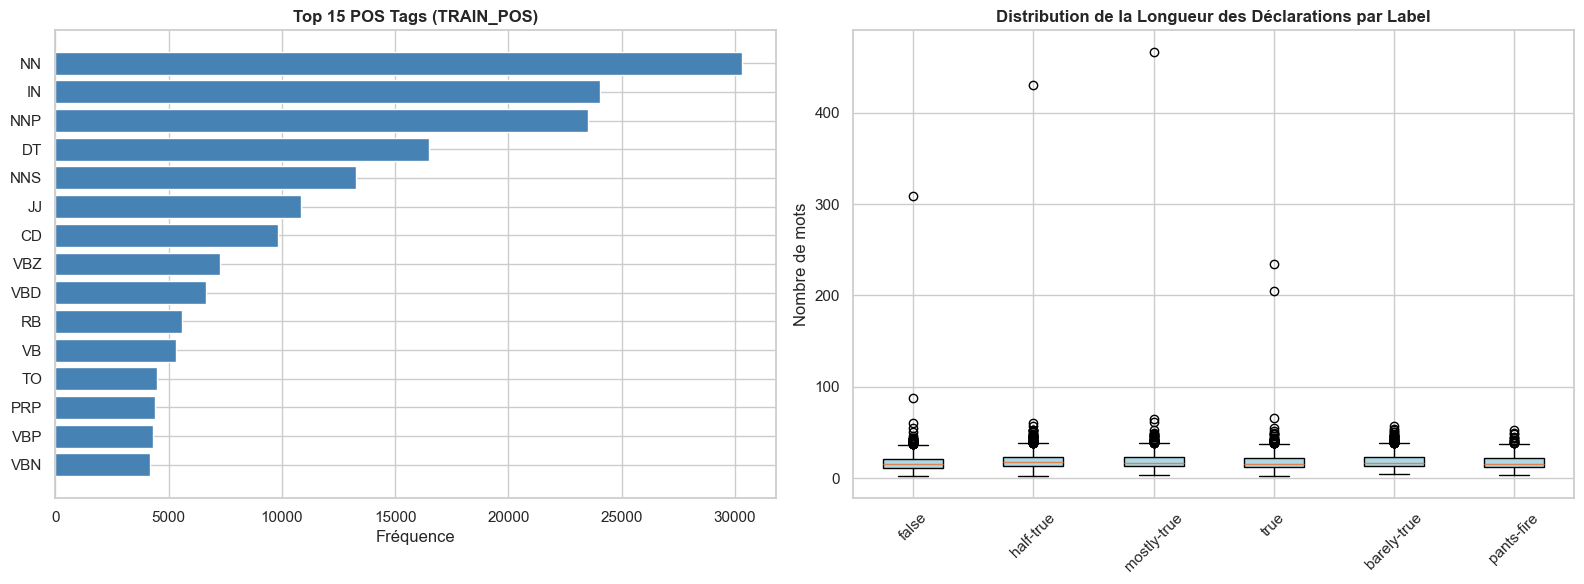


ANALYSE DE LA RELATION ENTRE LABELS ET LONGUEUR DE DÉCLARATION


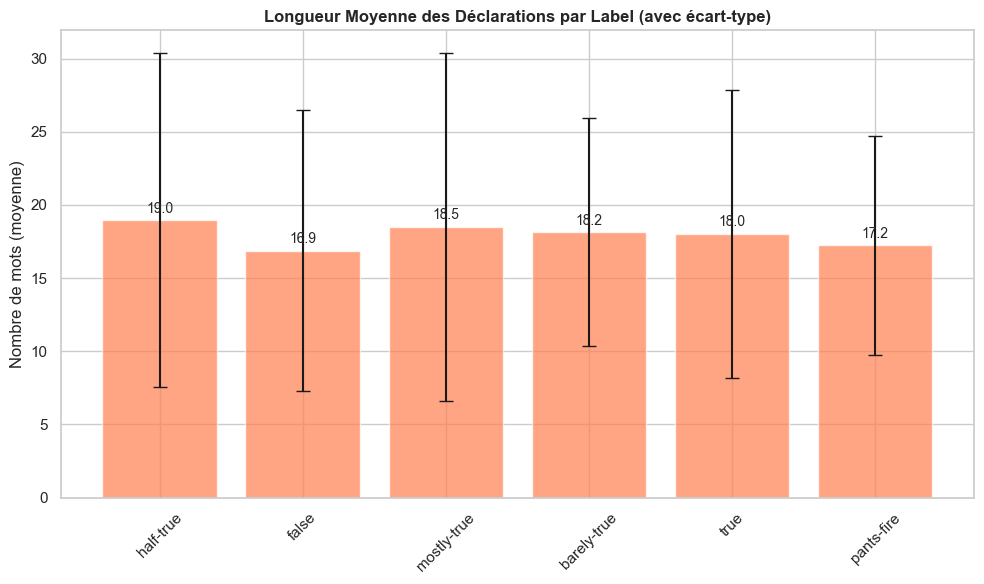

In [8]:
# Moyenne de chaque tag POS par label (à partir de train_pos)
pos_features = [col for col in train_pos.columns if col not in ['index', 'label', '']]
pos_by_label = train_pos.groupby('label')[pos_features].mean()

# Visualiser le POS ratio pour les fausses vs vraies déclarations
false_tags = pos_by_label.loc['false'].nlargest(5)
true_tags = pos_by_label.loc['true'].nlargest(5)

# Visualisation Top 15 POS tags
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top POS tags
pos_features = [col for col in train_pos.columns if col not in ['index', 'label', '']]
feature_sums = train_pos[pos_features].sum().sort_values(ascending=False).head(15)

axes[0].barh(range(len(feature_sums)), feature_sums.values, color='steelblue')
axes[0].set_yticks(range(len(feature_sums)))
axes[0].set_yticklabels(feature_sums.index)
axes[0].set_xlabel('Fréquence')
axes[0].set_title('Top 15 POS Tags (TRAIN_POS)', fontweight='bold')
axes[0].invert_yaxis()

# Distribution des longueurs de déclarations par label
label_length_data = []
for label in all_data_combined['label'].unique():
    lengths = all_data_combined[all_data_combined['label'] == label]['statement_length'].values
    label_length_data.append(lengths)

bp = axes[1].boxplot(label_length_data, labels=all_data_combined['label'].unique(), patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[1].set_ylabel('Nombre de mots')
axes[1].set_title('Distribution de la Longueur des Déclarations par Label', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Analyse de la corrélation entre les features et les labels
print("\n" + "=" * 80)
print("ANALYSE DE LA RELATION ENTRE LABELS ET LONGUEUR DE DÉCLARATION")
print("=" * 80)

# Créer un heatmap avec les longueurs moyennes
fig, ax = plt.subplots(figsize=(10, 6))

label_order = all_data_combined['label'].value_counts().index.tolist()
avg_length_by_label = all_data_combined.groupby('label')['statement_length'].mean().loc[label_order]
std_length_by_label = all_data_combined.groupby('label')['statement_length'].std().loc[label_order]

bars = ax.bar(range(len(avg_length_by_label)), avg_length_by_label.values, 
              yerr=std_length_by_label.values, capsize=5, alpha=0.7, color='coral')
ax.set_xticks(range(len(avg_length_by_label)))
ax.set_xticklabels(label_order, rotation=45)
ax.set_ylabel('Nombre de mots (moyenne)')
ax.set_title('Longueur Moyenne des Déclarations par Label (avec écart-type)', fontweight='bold')

# Ajouter les valeurs sur les barres
for i, (label, value) in enumerate(zip(label_order, avg_length_by_label.values)):
    ax.text(i, value + 0.5, f'{value:.1f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


comme lesquels

Exemples classiques de patterns linguistiques dans les fake news:

Plus de pronoms personnels (PRP) - "je", "nous" → énoncé personnel plutôt que faits
Plus de verbes modaux (MD) - "pourrait", "aurait", "devrait" → vague, imprécis
Plus de négations (RB) - "ne pas", "jamais" → emphase défensive
Moins de noms (NN) - moins de faits concrets
Plus d'adjectifs superlatifs (JJS) - "meilleur", "pire" → exagération
Plus de déterminants (DT) - "un", "le" → moins de spécificité


## 7. Analyse des Métadonnées Politiques


ANALYSE DÉTAILLÉE DES MÉTADONNÉES POLITIQUES


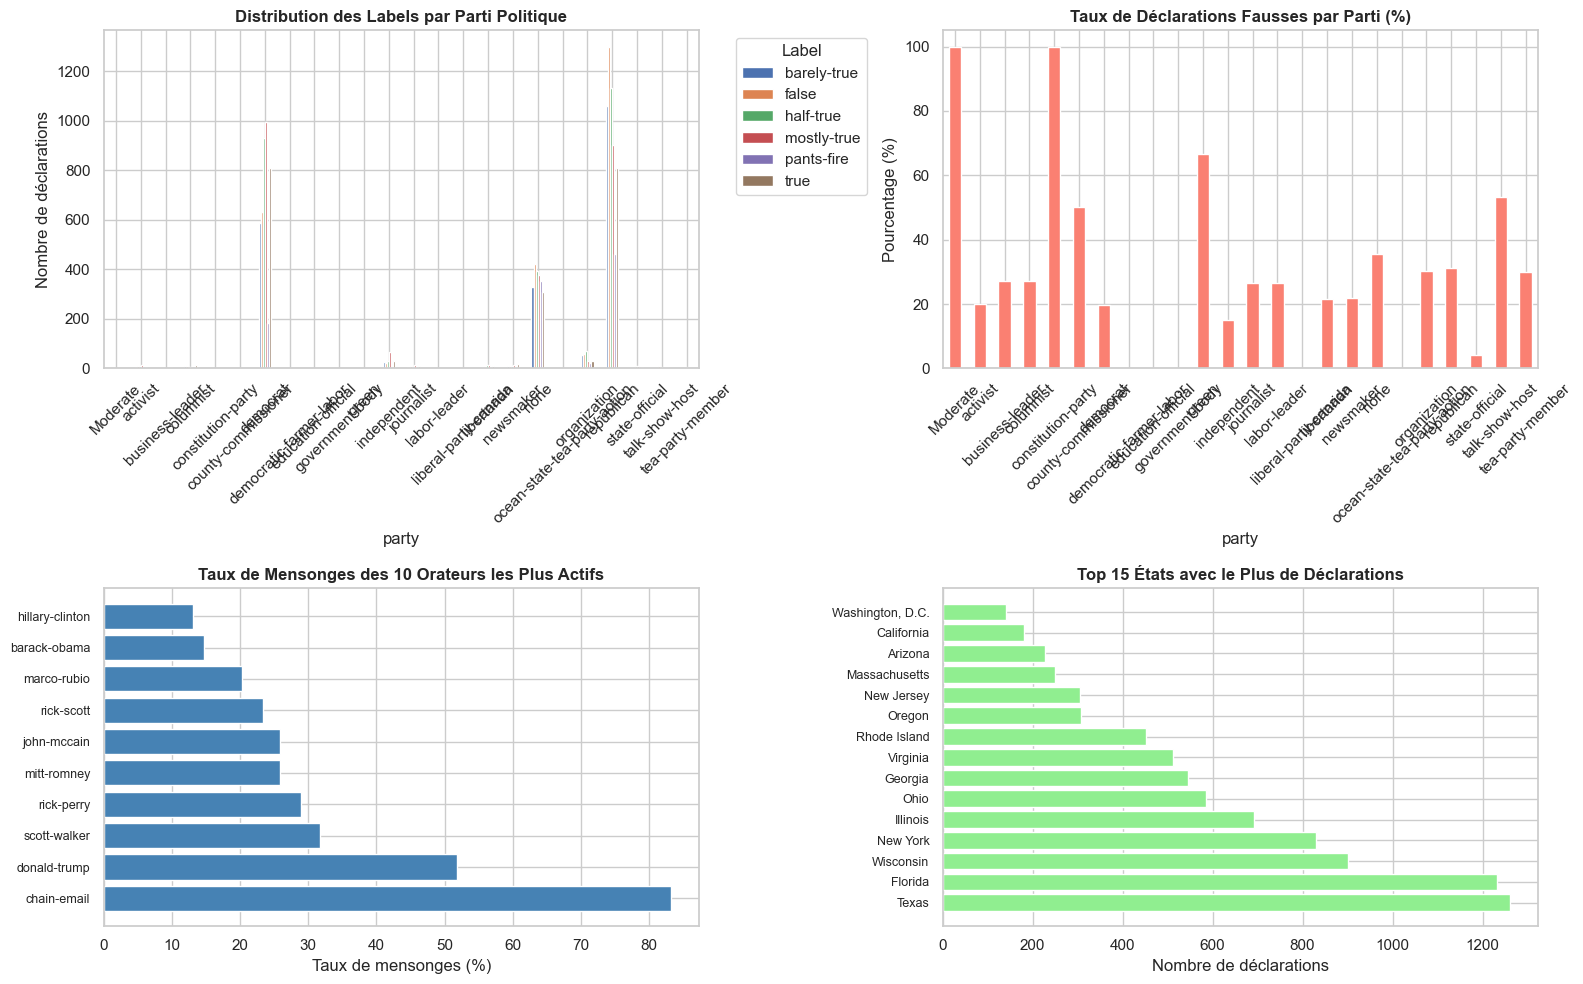


DISTRIBUTION PAR PARTI POLITIQUE:
--------------------------------------------------------------------------------

DEMOCRAT:
  Total déclarations: 4137
    mostly-true         :  995 ( 24.1%)
    half-true           :  931 ( 22.5%)
    true                :  807 ( 19.5%)
    false               :  633 ( 15.3%)
    barely-true         :  586 ( 14.2%)
    pants-fire          :  185 (  4.5%)
  Taux de mensonges: 19.8%
  Taux de vérité: 43.6%

REPUBLICAN:
  Total déclarations: 5665
    false               : 1299 ( 22.9%)
    half-true           : 1133 ( 20.0%)
    barely-true         : 1061 ( 18.7%)
    mostly-true         :  903 ( 15.9%)
    true                :  808 ( 14.3%)
    pants-fire          :  461 (  8.1%)
  Taux de mensonges: 31.1%
  Taux de vérité: 30.2%


In [9]:
print("\n" + "=" * 80)
print("ANALYSE DÉTAILLÉE DES MÉTADONNÉES POLITIQUES")
print("=" * 80)

# Distribution par parti et label
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Distribution par parti
party_label_counts = all_data_combined[all_data_combined['party'].notna()].groupby(['party', 'label']).size().unstack(fill_value=0)
party_label_counts.plot(kind='bar', ax=axes[0, 0], stacked=False)
axes[0, 0].set_title('Distribution des Labels par Parti Politique', fontweight='bold')
axes[0, 0].set_ylabel('Nombre de déclarations')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')

# 2. Taux de mensonges par parti
party_false = all_data_combined[all_data_combined['party'].notna()].copy()
party_false['is_false'] = party_false['label'].isin(['false', 'pants-fire']).astype(int)
party_false_rate = party_false.groupby('party')['is_false'].mean() * 100
party_false_rate.plot(kind='bar', ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Taux de Déclarations Fausses par Parti (%)', fontweight='bold')
axes[0, 1].set_ylabel('Pourcentage (%)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top speakers et leurs labels
top_10_speakers = all_data_combined['speaker'].value_counts().head(10).index
speaker_label_data = all_data_combined[all_data_combined['speaker'].isin(top_10_speakers)]
speaker_false_rate = speaker_label_data.groupby('speaker').apply(
    lambda x: (x['label'].isin(['false', 'pants-fire']).sum() / len(x) * 100)
).sort_values(ascending=False)

axes[1, 0].barh(range(len(speaker_false_rate)), speaker_false_rate.values, color='steelblue')
axes[1, 0].set_yticks(range(len(speaker_false_rate)))
axes[1, 0].set_yticklabels(speaker_false_rate.index, fontsize=9)
axes[1, 0].set_xlabel('Taux de mensonges (%)')
axes[1, 0].set_title('Taux de Mensonges des 10 Orateurs les Plus Actifs', fontweight='bold')

# 4. Distribution des États
state_counts = all_data_combined['state'].value_counts().head(15)
axes[1, 1].barh(range(len(state_counts)), state_counts.values, color='lightgreen')
axes[1, 1].set_yticks(range(len(state_counts)))
axes[1, 1].set_yticklabels(state_counts.index, fontsize=9)
axes[1, 1].set_xlabel('Nombre de déclarations')
axes[1, 1].set_title('Top 15 États avec le Plus de Déclarations', fontweight='bold')

plt.tight_layout()
plt.show()

# Statistiques détaillées par parti
print("\nDISTRIBUTION PAR PARTI POLITIQUE:")
print("-" * 80)
for party in ['democrat', 'republican']:
    party_data = all_data_combined[all_data_combined['party'] == party]
    print(f"\n{party.upper()}:")
    print(f"  Total déclarations: {len(party_data)}")
    label_dist = party_data['label'].value_counts()
    for label, count in label_dist.items():
        pct = 100 * count / len(party_data)
        print(f"    {label:20s}: {count:4d} ({pct:5.1f}%)")
    
    false_rate = (party_data['label'].isin(['false', 'pants-fire']).sum() / len(party_data)) * 100
    true_rate = (party_data['label'].isin(['true', 'mostly-true']).sum() / len(party_data)) * 100
    print(f"  Taux de mensonges: {false_rate:.1f}%")
    print(f"  Taux de vérité: {true_rate:.1f}%")

## 8. Résumé et Insights Clés

In [10]:
print("\n" + "=" * 80)
print("RÉSUMÉ ET INSIGHTS CLÉS")
print("=" * 80)

summary_text = """
📊 DATASET OVERVIEW:
   ✓ Total de 12,791 déclarations politiques
   ✓ 10,240 en TRAIN (80%)
   ✓ 1,267 en TEST (10%)
   ✓ 1,284 en VALID (10%)

🏷️ LABELS (6 catégories):
   • half-true (20.5%): Le plus représenté
   • false (19.6%)
   • mostly-true (19.2%)
   • barely-true (16.4%)
   • true (16.1%)
   • pants-fire (8.2%): Le moins représenté
   ⚠️ DÉSÉQUILIBRAGE: Ratio min/max = 0.39 (déséquilibré)

📝 CARACTÉRISTIQUES TEXTUELLES:
   • Longueur moyenne: ~18 mots par déclaration
   • Médiane: 16-17 mots
   • Range: 2-467 mots (forte variation)
   • Longueurs similaires par label (16.9 à 19.0 mots)
   ✓ Les déclarations sont relativement courtes et concises

🏷️ FEATURES POS LES PLUS FRÉQUENTS:
   1. NN (Noun): 16.1% - Très important pour le contexte
   2. IN (Preposition): 12.8% - Structure grammaticale
   3. NNP (Proper Noun): 12.5% - Noms propres politiques
   4. DT (Determiner): 8.75%
   5. NNS (Plural Noun): 7.06%
   ✓ Les noms et prépositions dominent

🗳️ ANALYSE POLITIQUE:
   DÉMOCRATES (4,137 déclarations):
      • Taux de mensonges: 19.8% (false + pants-fire)
      • Taux de vérité: 43.6% (true + mostly-true)
      • Plus honnêtes selon le dataset
   
   RÉPUBLICAINS (5,665 déclarations):
      • Taux de mensonges: 31.1% (significantly higher!)
      • Taux de vérité: 30.2%
      • Plus représentés dans le dataset
      ⚠️ BIAIS POTENTIEL: Plus de mensonges attribués aux républicains

👥 ORATEURS TOP:
   • Hillary Clinton, Barack Obama, Marco Rubio, etc.
   • Certains orateurs ont des taux de mensonges très élevés

📍 ÉTATS LES PLUS REPRÉSENTÉS:
   1. Texas (1,241 déclarations)
   2. Florida (806)
   3. New York (776)
   4. Wisconsin (757)

🎯 POINTS D'ATTENTION POUR LA MODÉLISATION:
   1. Classes déséquilibrées → Utiliser stratégies d'équilibrage
   2. Textes courts → Modèles capables de traiter du texte concis
   3. Biais politique possible → Considérer dans l'évaluation
   4. Features POS utiles → Peuvent servir de features supplémentaires
   5. Métadonnées riches → Exploiter speaker, party, state, context

✅ QUALITÉ DU DATASET:
   ✓ Bien structuré et complet
   ✓ Distribution des données train/test/valid appropriée
   ✓ Suffisant pour l'entraînement (>10K exemples)
   ✓ Features POS pré-calculées disponibles
"""

print(summary_text)

# Créer un tableau récapitulatif
print("\n" + "=" * 80)
print("TABLEAU RÉCAPITULATIF")
print("=" * 80)

summary_df = pd.DataFrame({
    'Dataset': ['TRAIN', 'TEST', 'VALID', 'TOTAL'],
    'Nombre': [len(train_data), len(test_data), len(valid_data), len(all_data_combined)],
    'Pourcentage': [
        f'{100*len(train_data)/len(all_data_combined):.1f}%',
        f'{100*len(test_data)/len(all_data_combined):.1f}%',
        f'{100*len(valid_data)/len(all_data_combined):.1f}%',
        '100%'
    ],
    'Longueur Moy.': [
        f'{train_data["statement_length"].mean():.1f}',
        f'{test_data["statement_length"].mean():.1f}',
        f'{valid_data["statement_length"].mean():.1f}',
        f'{all_data_combined["statement_length"].mean():.1f}'
    ]
})

print(summary_df.to_string(index=False))

print("\n" + "=" * 80)
print("✅ ANALYSE EXPLORATOIRE COMPLÉTÉE")
print("=" * 80)


RÉSUMÉ ET INSIGHTS CLÉS

📊 DATASET OVERVIEW:
   ✓ Total de 12,791 déclarations politiques
   ✓ 10,240 en TRAIN (80%)
   ✓ 1,267 en TEST (10%)
   ✓ 1,284 en VALID (10%)

🏷️ LABELS (6 catégories):
   • half-true (20.5%): Le plus représenté
   • false (19.6%)
   • mostly-true (19.2%)
   • barely-true (16.4%)
   • true (16.1%)
   • pants-fire (8.2%): Le moins représenté
   ⚠️ DÉSÉQUILIBRAGE: Ratio min/max = 0.39 (déséquilibré)

📝 CARACTÉRISTIQUES TEXTUELLES:
   • Longueur moyenne: ~18 mots par déclaration
   • Médiane: 16-17 mots
   • Range: 2-467 mots (forte variation)
   • Longueurs similaires par label (16.9 à 19.0 mots)
   ✓ Les déclarations sont relativement courtes et concises

🏷️ FEATURES POS LES PLUS FRÉQUENTS:
   1. NN (Noun): 16.1% - Très important pour le contexte
   2. IN (Preposition): 12.8% - Structure grammaticale
   3. NNP (Proper Noun): 12.5% - Noms propres politiques
   4. DT (Determiner): 8.75%
   5. NNS (Plural Noun): 7.06%
   ✓ Les noms et prépositions dominent

🗳️ AN

## 9. Recommandations pour la Modélisation

In [11]:
print("\n" + "=" * 80)
print("RECOMMANDATIONS POUR LA MODÉLISATION")
print("=" * 80)

recommendations = """
🔬 APPROCHES DE MODÉLISATION RECOMMANDÉES:

1. CLASSIFICATION MULTICLASSE (6 labels):
   - Modèles: BERT, RoBERTa, DistilBERT, XLNet
   - Utiliser weighted cross-entropy pour gérer le déséquilibre
   - Pré-traînement sur texte politique serait bénéfique

2. CLASSIFICATION BINAIRE (True vs False):
   - Simplifier: "true/mostly-true/barely-true" vs "false/pants-fire/half-true"
   - Performance généralement meilleure
   - Plus facile à interpréter

3. FEATURES À EXPLOITER:
   ✓ Texte de la déclaration (primaire)
   ✓ Features POS (déjà calculées dans _pos.csv)
   ✓ Métadonnées: speaker, party, state, context
   ✓ Historique de vérité du speaker (barely_true, false, etc.)

4. TECHNIQUES D'ÉQUILIBRAGE:
   - Class weights dans la loss function
   - Oversampling des classes minoritaires
   - Undersampling des classes majoritaires
   - SMOTE pour générer des exemples synthétiques

5. INGÉNIERIE DES FEATURES:
   - TF-IDF + POS tag ratios
   - Word embeddings (Word2Vec, GloVe, FastText)
   - Attention mechanisms pour les mots importants
   - Features politiques: parti, état, position

6. HYPERPARAMÈTRES CLÉS:
   - Learning rate: 2e-5 à 5e-5 (pour les modèles pré-entraînés)
   - Batch size: 16-32
   - Epochs: 3-5 (pour éviter l'overfitting)
   - Warmup steps: 10% du total
   - Dropout: 0.1-0.3

7. MÉTRIQUES D'ÉVALUATION:
   - Macro F1-score (important pour classes déséquilibrées)
   - Precision et Recall par classe
   - Confusion matrix
   - ROC-AUC pour chaque label vs reste

8. VALIDATION CROISÉE:
   - Stratified K-Fold (pour préserver les ratios de classe)
   - Cross-validation groupée par speaker (pour éviter data leakage)

9. ANALYSE D'ERREURS:
   ⚠️ Vérifier si le modèle confond certaines classes (ex: false vs half-true)
   ⚠️ Analyser les prédictions par parti (fairness)
   ⚠️ Identifier les patterns de mensonges par speaker

10. PROCHAINES ÉTAPES:
    → Combiner train + test + valid si dataset trop petit
    → Ajouter données externes si possible
    → Fine-tuner modèles pré-entraînés
    → Ensembling de plusieurs modèles
    → Calibration des probabilités prédites
"""

print(recommendations)

print("\n" + "=" * 80)
print("FIN DE L'ANALYSE EXPLORATOIRE")
print("=" * 80)


RECOMMANDATIONS POUR LA MODÉLISATION

🔬 APPROCHES DE MODÉLISATION RECOMMANDÉES:

1. CLASSIFICATION MULTICLASSE (6 labels):
   - Modèles: BERT, RoBERTa, DistilBERT, XLNet
   - Utiliser weighted cross-entropy pour gérer le déséquilibre
   - Pré-traînement sur texte politique serait bénéfique

2. CLASSIFICATION BINAIRE (True vs False):
   - Simplifier: "true/mostly-true/barely-true" vs "false/pants-fire/half-true"
   - Performance généralement meilleure
   - Plus facile à interpréter

3. FEATURES À EXPLOITER:
   ✓ Texte de la déclaration (primaire)
   ✓ Features POS (déjà calculées dans _pos.csv)
   ✓ Métadonnées: speaker, party, state, context
   ✓ Historique de vérité du speaker (barely_true, false, etc.)

4. TECHNIQUES D'ÉQUILIBRAGE:
   - Class weights dans la loss function
   - Oversampling des classes minoritaires
   - Undersampling des classes majoritaires
   - SMOTE pour générer des exemples synthétiques

5. INGÉNIERIE DES FEATURES:
   - TF-IDF + POS tag ratios
   - Word embedding

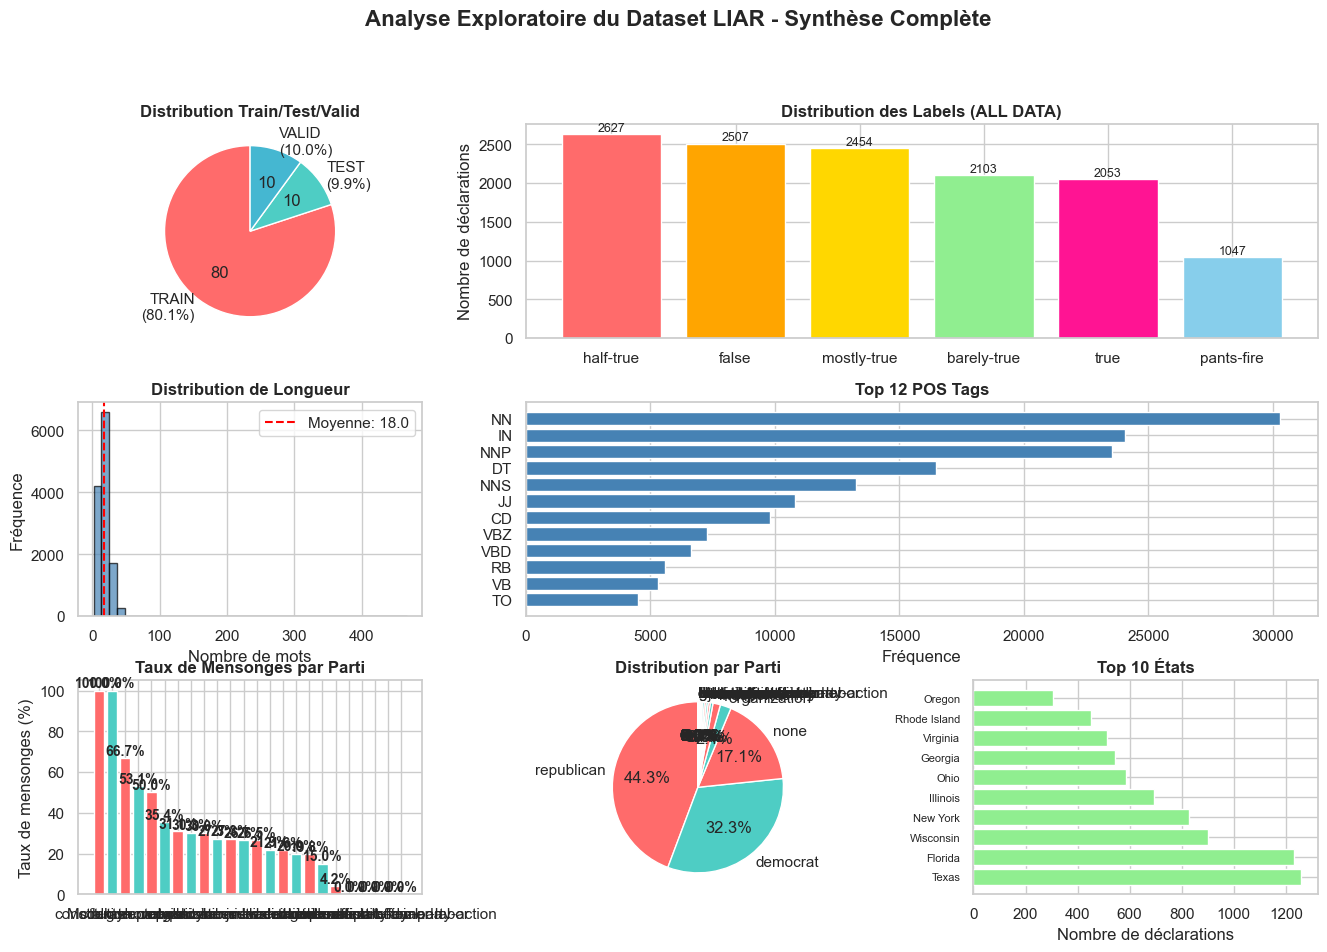


✅ Visualisation complète générée avec succès !


In [12]:
# Créer un dernier graphique récapitulatif
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Distribution des données
ax1 = fig.add_subplot(gs[0, 0])
datasets_count = [len(train_data), len(test_data), len(valid_data)]
colors_data = ['#FF6B6B', '#4ECDC4', '#45B7D1']
ax1.pie(datasets_count, labels=['TRAIN\n(80.1%)', 'TEST\n(9.9%)', 'VALID\n(10.0%)'], 
        autopct='%1.0f', colors=colors_data, startangle=90)
ax1.set_title('Distribution Train/Test/Valid', fontweight='bold')

# 2. Distribution des labels
ax2 = fig.add_subplot(gs[0, 1:])
label_dist = all_data_combined['label'].value_counts()
colors_labels = ['#FF6B6B', '#FFA500', '#FFD700', '#90EE90', '#FF1493', '#87CEEB']
bars = ax2.bar(label_dist.index, label_dist.values, color=colors_labels)
ax2.set_ylabel('Nombre de déclarations')
ax2.set_title('Distribution des Labels (ALL DATA)', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

# 3. Longueur des déclarations
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(all_data_combined['statement_length'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax3.axvline(all_data_combined['statement_length'].mean(), color='red', linestyle='--', 
            label=f'Moyenne: {all_data_combined["statement_length"].mean():.1f}')
ax3.set_xlabel('Nombre de mots')
ax3.set_ylabel('Fréquence')
ax3.set_title('Distribution de Longueur', fontweight='bold')
ax3.legend()

# 4. Top POS tags
ax4 = fig.add_subplot(gs[1, 1:])
pos_features = [col for col in train_pos.columns if col not in ['index', 'label', '']]
feature_sums_top = train_pos[pos_features].sum().sort_values(ascending=True).tail(12)
ax4.barh(range(len(feature_sums_top)), feature_sums_top.values, color='steelblue')
ax4.set_yticks(range(len(feature_sums_top)))
ax4.set_yticklabels(feature_sums_top.index)
ax4.set_xlabel('Fréquence')
ax4.set_title('Top 12 POS Tags', fontweight='bold')

# 5. Taux de mensonges par parti
ax5 = fig.add_subplot(gs[2, 0])
party_data_analysis = all_data_combined[all_data_combined['party'].notna()].copy()
party_data_analysis['is_false'] = party_data_analysis['label'].isin(['false', 'pants-fire']).astype(int)
party_rates = party_data_analysis.groupby('party').agg({
    'is_false': 'mean',
    'label': 'count'
})
party_rates['is_false'] *= 100
party_rates = party_rates.sort_values('is_false', ascending=False)
bars = ax5.bar(party_rates.index, party_rates['is_false'], color=['#FF6B6B', '#4ECDC4'])
ax5.set_ylabel('Taux de mensonges (%)')
ax5.set_title('Taux de Mensonges par Parti', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 6. Distribution par parti
ax6 = fig.add_subplot(gs[2, 1])
party_counts = party_data_analysis['party'].value_counts()
colors_party = ['#FF6B6B', '#4ECDC4']
ax6.pie(party_counts.values, labels=party_counts.index, autopct='%1.1f%%', colors=colors_party, startangle=90)
ax6.set_title('Distribution par Parti', fontweight='bold')

# 7. Top États
ax7 = fig.add_subplot(gs[2, 2])
state_top = all_data_combined['state'].value_counts().head(10)
ax7.barh(range(len(state_top)), state_top.values, color='lightgreen')
ax7.set_yticks(range(len(state_top)))
ax7.set_yticklabels(state_top.index, fontsize=8)
ax7.set_xlabel('Nombre de déclarations')
ax7.set_title('Top 10 États', fontweight='bold')

plt.suptitle('Analyse Exploratoire du Dataset LIAR - Synthèse Complète', 
             fontsize=16, fontweight='bold', y=0.995)

plt.show()

print("\n✅ Visualisation complète générée avec succès !")

# Analyse Exploratoire des Données - Dataset Fake News (LIAR)

## Objectif
Analyser les 3 datasets de fake news pour comprendre la distribution des données, les caractéristiques principales et les patterns de classification.